# MSA length distribution: end-to-end in-memory example

This notebook demonstrates a usage pattern enabled by Sailfish being a Python package: skipping disk I/O entirely.

Instead of simulating MSAs to disk and then reading them back in a separate script, we simulate many replicates and record only the statistic we care about — the resulting MSA length — directly in memory. This avoids writing (and later parsing) full alignment files when only a single attribute is needed.

We fix a root length, tree, and indel model, then look at the distribution of simulated MSA lengths across many replicates.

In [2]:
from ete3 import Tree
import matplotlib.pyplot as plt

from msasim import SimProtocol, Simulator
from msasim.distributions import ZipfDistribution

## Tree

Generate a random 10-taxon tree with ete3 and export it as newick for Sailfish.

In [13]:
tree = Tree()
tree.populate(5, random_branches=True)
newick_tree = tree.write(format=1) # no bootstrap values
newick_tree

'((aaaaaaaaaa:0.348017,(aaaaaaaaab:0.551167,aaaaaaaaac:0.988368):0.327685):0.38234,(aaaaaaaaad:0.568111,aaaaaaaaae:0.456489):0.291567);'

## Protocol and simulator

Built once, outside the replicate loop. Indels only — no substitution model.

In [14]:
ROOT_LENGTH = 200
N_REPLICATES = 10000

protocol = SimProtocol(
    tree=newick_tree,
    root_seq_size=ROOT_LENGTH,
    deletion_rate=0.05,
    insertion_rate=0.05,
    deletion_dist=ZipfDistribution(1.7, 50),
    insertion_dist=ZipfDistribution(1.7, 50),
)

simulator = Simulator(protocol)

## Simulate and collect lengths

For each replicate we reseed the protocol and simulate. We only keep the MSA length — nothing is written to disk.

In [15]:
lengths = []

for _ in range(N_REPLICATES):
    msa = simulator()
    lengths.append(msa.get_length())

## Distribution of MSA lengths

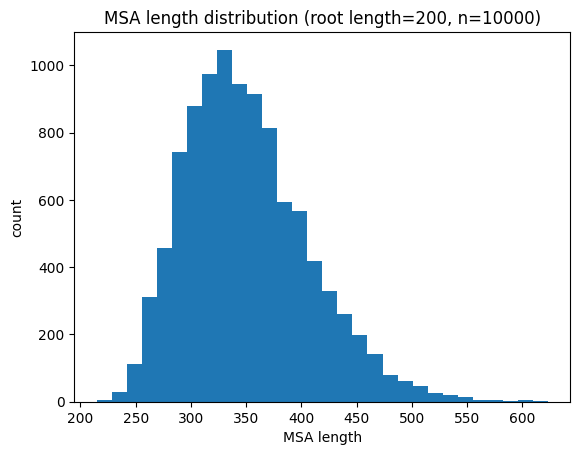

In [16]:
plt.hist(lengths, bins=30)
plt.xlabel("MSA length")
plt.ylabel("count")
plt.title(f"MSA length distribution (root length={ROOT_LENGTH}, n={N_REPLICATES})")
plt.show()